In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load per‑subject summaries for lag models
rf = pd.read_csv("rf_subject_metrics_lag.csv")
cat = pd.read_csv("cat_subject_metrics_lag.csv")

# Keep only subject id and total‑error RMSE; rename for clarity
rf = rf[["sub_id", "RMSE_total_error"]].rename(
    columns={"RMSE_total_error": "RMSE_total_error_RF"}
)
cat = cat[["sub_id", "RMSE_total_error"]].rename(
    columns={"RMSE_total_error": "RMSE_total_error_Cat"}
)

# Merge on subject id (inner join so only common subjects are kept)
df = pd.merge(rf, cat, on="sub_id", how="inner").sort_values("sub_id")

display(df)

,sub_id,RMSE_total_error_RF,RMSE_total_error_Cat
0,3,0.114424,0.107934
1,4,0.158173,0.137127
2,5,0.165847,0.136008
3,6,0.100801,0.098408
4,8,0.140781,0.126281
5,11,0.331742,0.223805
6,12,0.105542,0.103370
7,13,0.306721,0.243482
8,15,0.144240,0.128523
9,16,0.109816,0.107236


In [ ]:
# Prepare positions for grouped bars
subjects = df["sub_id"].astype(str).values
x = np.arange(len(subjects))
width = 0.35  # bar width

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, df["RMSE_total_error_RF"], width, label="Random Forest (lag)")
plt.bar(x + width/2, df["RMSE_total_error_Cat"], width, label="CatBoost (lag)")

plt.xlabel("Subject")
plt.ylabel("RMSE total error")
plt.title("Subject‑level RMSE of total error: Random Forest vs CatBoost (lag features)")
plt.xticks(x, subjects, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("rmse_total_error_RF_vs_Cat_per_subject.png", dpi=300)
plt.close()

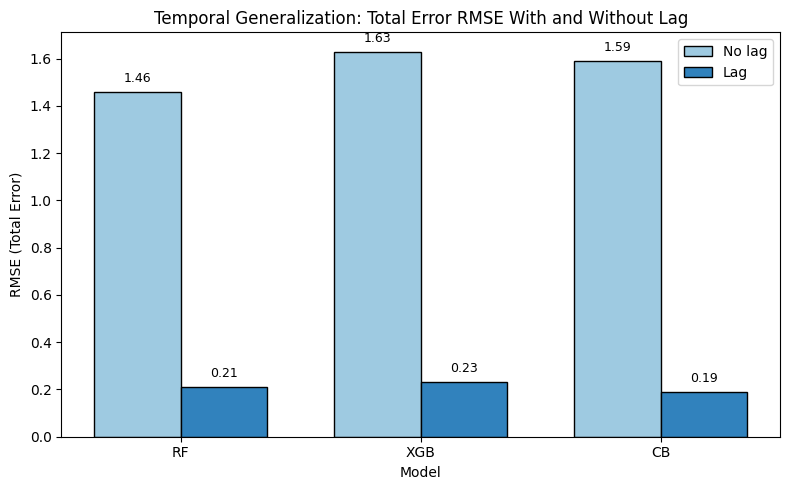

In [3]:
import matplotlib.pyplot as plt
import numpy as np

models = ["RF", "XGB", "CB"]
rmse_no_lag = [1.46, 1.63, 1.59]
rmse_lag = [0.21, 0.23, 0.19]

x = np.arange(len(models))
width = 0.36

plt.figure(figsize=(8, 5))

bars1 = plt.bar(
    x - width/2,
    rmse_no_lag,
    width,
    label="No lag",
    color="#9ecae1",
    edgecolor="black"
)

bars2 = plt.bar(
    x + width/2,
    rmse_lag,
    width,
    label="Lag",
    color="#3182bd",
    edgecolor="black"
)

plt.xticks(x, models)
plt.ylabel("RMSE (Total Error)")
plt.xlabel("Model")
plt.title("Temporal Generalization: Total Error RMSE With and Without Lag")
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.03,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

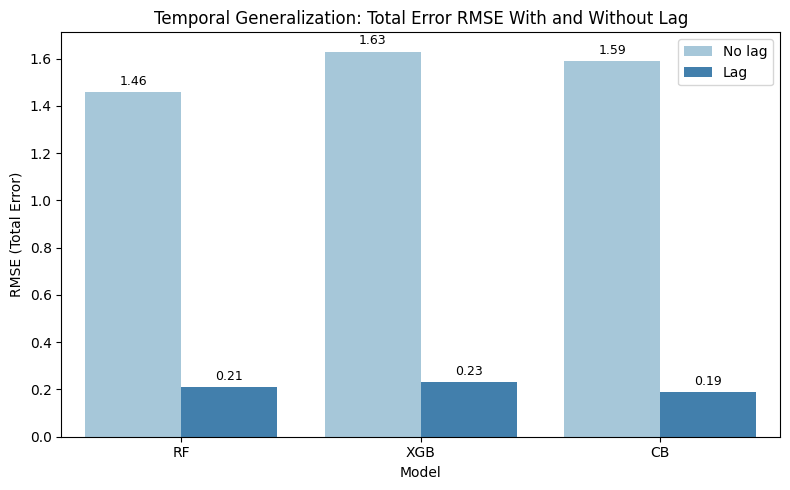

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = pd.DataFrame({
    "Model": ["RF", "RF", "XGB", "XGB", "CB", "CB"],
    "Condition": ["No lag", "Lag", "No lag", "Lag", "No lag", "Lag"],
    "RMSE": [1.46, 0.21, 1.63, 0.23, 1.59, 0.19]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_plot,
    x="Model",
    y="RMSE",
    hue="Condition",
    palette=["#9ecae1", "#3182bd"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.ylabel("RMSE (Total Error)")
plt.xlabel("Model")
plt.title("Temporal Generalization: Total Error RMSE With and Without Lag")
plt.legend(title="")
plt.tight_layout()
plt.show()